# Concurrent NN Compression for Spatio-Temporal Data — Offline Training & Evaluation
- **Base Model**: 4 → 64 → 64 → 32 → 4 (6,692 parameters)
- **Medium Model**: 4 → 96 → 96 → 48 → 4 (14,644 parameters)
- **Large Model**: 4 → 128 → 128 → 64 → 4 (25,668 parameters)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# Data path: /kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv


/kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv


In [2]:
"""Unified Training Utilities for Concurrent NN Compression for Spatio-Temporal Data"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import pyarrow.csv as pv
from torcheval.metrics import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure
import matplotlib.pyplot as plt
import time
import os
import json


class SpatioTemporalDataset(Dataset):
    """Spatio-temporal spatio-temporal dataset with min-max normalization to [0, 1]."""

    def __init__(self, filepath):
        print(f"[Data] Loading dataset from {filepath}")
        read_options = pv.ReadOptions(
            column_names=['x', 'y', 'z', 't', 'Vx', 'Vy', 'Pressure', 'TKE']
        )
        table = pv.read_csv(filepath, read_options=read_options)
        data = table.to_pandas().values
        self.inputs = data[:, :4].astype(np.float32)
        self.targets = data[:, 4:].astype(np.float32)
        print("[Data] Applying min-max normalization to [0, 1] range")
        self.input_min = self.inputs.min(axis=0)
        self.input_max = self.inputs.max(axis=0)
        self.input_range = self.input_max - self.input_min
        self.input_range[self.input_range == 0] = 1.0
        self.inputs = (self.inputs - self.input_min) / self.input_range
        self.target_min = self.targets.min(axis=0)
        self.target_max = self.targets.max(axis=0)
        self.target_range = self.target_max - self.target_min
        self.target_range[self.target_range == 0] = 1.0
        self.targets = (self.targets - self.target_min) / self.target_range
        print(f"[Data] Loaded {len(self):,} samples | Input: {self.inputs.shape} | Target: {self.targets.shape}")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.from_numpy(self.inputs[idx]), torch.from_numpy(self.targets[idx])

    def denormalize_inputs(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.cpu().numpy()
        return normalized * self.input_range + self.input_min

    def denormalize_targets(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.cpu().numpy()
        return normalized * self.target_range + self.target_min


class BaseCompressor(nn.Module):
    """Base compression network: 4 -> 64 -> 64 -> 32 -> 4"""

    def __init__(self):
        super(BaseCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        return self.network(x)


class MediumCompressor(nn.Module):
    """Medium compression network: 4 -> 96 -> 96 -> 48 -> 4"""

    def __init__(self):
        super(MediumCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 96),
            nn.ReLU(),
            nn.Linear(96, 96),
            nn.ReLU(),
            nn.Linear(96, 48),
            nn.ReLU(),
            nn.Linear(48, 4)
        )

    def forward(self, x):
        return self.network(x)


class LargeCompressor(nn.Module):
    """Large compression network: 4 -> 128 -> 128 -> 64 -> 4"""

    def __init__(self):
        super(LargeCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.network(x)


def compute_psnr_ssim(predictions, targets, device):
    """Compute PSNR and SSIM for regression data using per-point comparison (kernel_size=1)."""
    predictions = predictions.to(device)
    targets = targets.to(device)

    psnr_metric = PeakSignalNoiseRatio().to(device)
    psnr_metric.update(predictions, targets)
    psnr = psnr_metric.compute().item()

    pred_ssim = predictions.view(-1, 1, 1, predictions.shape[1])
    target_ssim = targets.view(-1, 1, 1, targets.shape[1])
    pred_ssim = pred_ssim.permute(1, 2, 0, 3)
    target_ssim = target_ssim.permute(1, 2, 0, 3)

    ssim_metric = StructuralSimilarityIndexMeasure(
        gaussian_kernel=False, kernel_size=1
    ).to(device)
    ssim_metric.update(pred_ssim, target_ssim)
    ssim = ssim_metric.compute().item()

    return psnr, ssim


def compute_relative_error(predictions, targets):
    """Compute relative L2 norm error as a percentage."""
    target_norm = torch.norm(targets)
    error = torch.norm(predictions - targets)
    return (error / target_norm * 100).item()


def train_model(model, train_loader, dataset, device, epochs, model_name, output_dir):
    """Train a compression model and save weights, normalization parameters, and metrics."""
    os.makedirs(output_dir, exist_ok=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    metrics = {'loss': [], 'psnr': [], 'ssim': [], 'relative_error': [], 'time_per_epoch': []}
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n[Train] Model: {model_name}")
    print(f"[Train] Samples: {len(dataset):,} | Epochs: {epochs} | Device: {device}")
    print(f"[Train] Parameters: {total_params:,} | Size: {total_params * 4 / 1024:.2f} KB\n")
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        epoch_loss = 0.0
        all_predictions = []
        all_targets = []
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            all_predictions.append(outputs.detach())
            all_targets.append(targets)
        epoch_loss /= len(train_loader)
        metrics['loss'].append(epoch_loss)
        all_predictions = torch.cat(all_predictions, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        psnr, ssim = compute_psnr_ssim(all_predictions, all_targets, device)
        rel_error = compute_relative_error(all_predictions, all_targets)
        metrics['psnr'].append(psnr)
        metrics['ssim'].append(ssim)
        metrics['relative_error'].append(rel_error)
        epoch_time = time.time() - epoch_start
        metrics['time_per_epoch'].append(epoch_time)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>3}/{epochs}: Loss={epoch_loss:.6f}, "
                  f"PSNR={psnr:.2f} dB, SSIM={ssim:.4f}, "
                  f"Rel. Error={rel_error:.2f}%, Time={epoch_time:.2f}s")
    model_path = os.path.join(output_dir, f'{model_name}_minmax.pth')
    torch.save(model.state_dict(), model_path)
    print(f"\n[Train] Model saved: {model_path}")
    norm_params = {
        'input_min': dataset.input_min.tolist(),
        'input_max': dataset.input_max.tolist(),
        'input_range': dataset.input_range.tolist(),
        'target_min': dataset.target_min.tolist(),
        'target_max': dataset.target_max.tolist(),
        'target_range': dataset.target_range.tolist()
    }
    norm_path = os.path.join(output_dir, f'{model_name}_normalization.json')
    with open(norm_path, 'w') as f:
        json.dump(norm_params, f, indent=2)
    print(f"[Train] Normalization parameters saved: {norm_path}")
    print(f"\n[Train] Training completed for {model_name}")
    print(f"  Final Loss:           {metrics['loss'][-1]:.6f}")
    print(f"  Final PSNR:           {metrics['psnr'][-1]:.2f} dB")
    print(f"  Final SSIM:           {metrics['ssim'][-1]:.4f}")
    print(f"  Final Relative Error: {metrics['relative_error'][-1]:.2f}%")
    print(f"  PSNR Improvement:     {metrics['psnr'][0]:.2f} → {metrics['psnr'][-1]:.2f} dB "
          f"({metrics['psnr'][-1]-metrics['psnr'][0]:+.2f} dB)\n")
    return metrics


def export_metrics_csv(metrics, output_path):
    """Export training metrics history to CSV."""
    df = pd.DataFrame(metrics)
    df['epoch'] = range(1, len(df) + 1)
    df = df[['epoch', 'loss', 'psnr', 'ssim', 'relative_error', 'time_per_epoch']]
    df.to_csv(output_path, index=False)
    print(f"[Export] Metrics saved: {output_path}")

In [3]:
DATA_FILE = "/kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv"
EPOCHS = 150
BATCH_SIZE = 512
TIMESTEP = 0.0396

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Config] Device: {device}")
print(f"[Config] Epochs: {EPOCHS} | Batch Size: {BATCH_SIZE}")

dataset = SpatioTemporalDataset(DATA_FILE)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

[Config] Device: cuda
[Config] Epochs: 150 | Batch Size: 512
[Data] Loading dataset from /kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv
[Data] Applying min-max normalization to [0, 1] range
[Data] Loaded 7,919,100 samples | Input: (7919100, 4) | Target: (7919100, 4)


---
## 1. Base Model (64-64-32) — Training

In [4]:
BASE_OUTPUT_DIR = "/kaggle/working/results/base_model_offline"

base_model = BaseCompressor().to(device)

base_metrics = train_model(
    model=base_model,
    train_loader=train_loader,
    dataset=dataset,
    device=device,
    epochs=EPOCHS,
    model_name='base_model',
    output_dir=BASE_OUTPUT_DIR
)

export_metrics_csv(base_metrics, f"{BASE_OUTPUT_DIR}/base_model_metrics.csv")


[Train] Model: base_model
[Train] Samples: 7,919,100 | Epochs: 150 | Device: cuda
[Train] Parameters: 6,692 | Size: 26.14 KB

  Epoch   1/150: Loss=0.005590, PSNR=22.53 dB, SSIM=0.9015, Rel. Error=13.37%, Time=77.94s
  Epoch  10/150: Loss=0.001706, PSNR=27.68 dB, SSIM=0.9284, Rel. Error=7.39%, Time=76.90s
  Epoch  20/150: Loss=0.001279, PSNR=28.93 dB, SSIM=0.9546, Rel. Error=6.40%, Time=76.79s
  Epoch  30/150: Loss=0.001125, PSNR=29.49 dB, SSIM=0.9610, Rel. Error=6.00%, Time=77.22s
  Epoch  40/150: Loss=0.001029, PSNR=29.88 dB, SSIM=0.9651, Rel. Error=5.74%, Time=76.67s
  Epoch  50/150: Loss=0.000966, PSNR=30.15 dB, SSIM=0.9679, Rel. Error=5.56%, Time=76.91s
  Epoch  60/150: Loss=0.000926, PSNR=30.34 dB, SSIM=0.9680, Rel. Error=5.44%, Time=76.95s
  Epoch  70/150: Loss=0.000898, PSNR=30.47 dB, SSIM=0.9698, Rel. Error=5.36%, Time=76.73s
  Epoch  80/150: Loss=0.000875, PSNR=30.58 dB, SSIM=0.9699, Rel. Error=5.29%, Time=76.86s
  Epoch  90/150: Loss=0.000857, PSNR=30.67 dB, SSIM=0.9700, Re

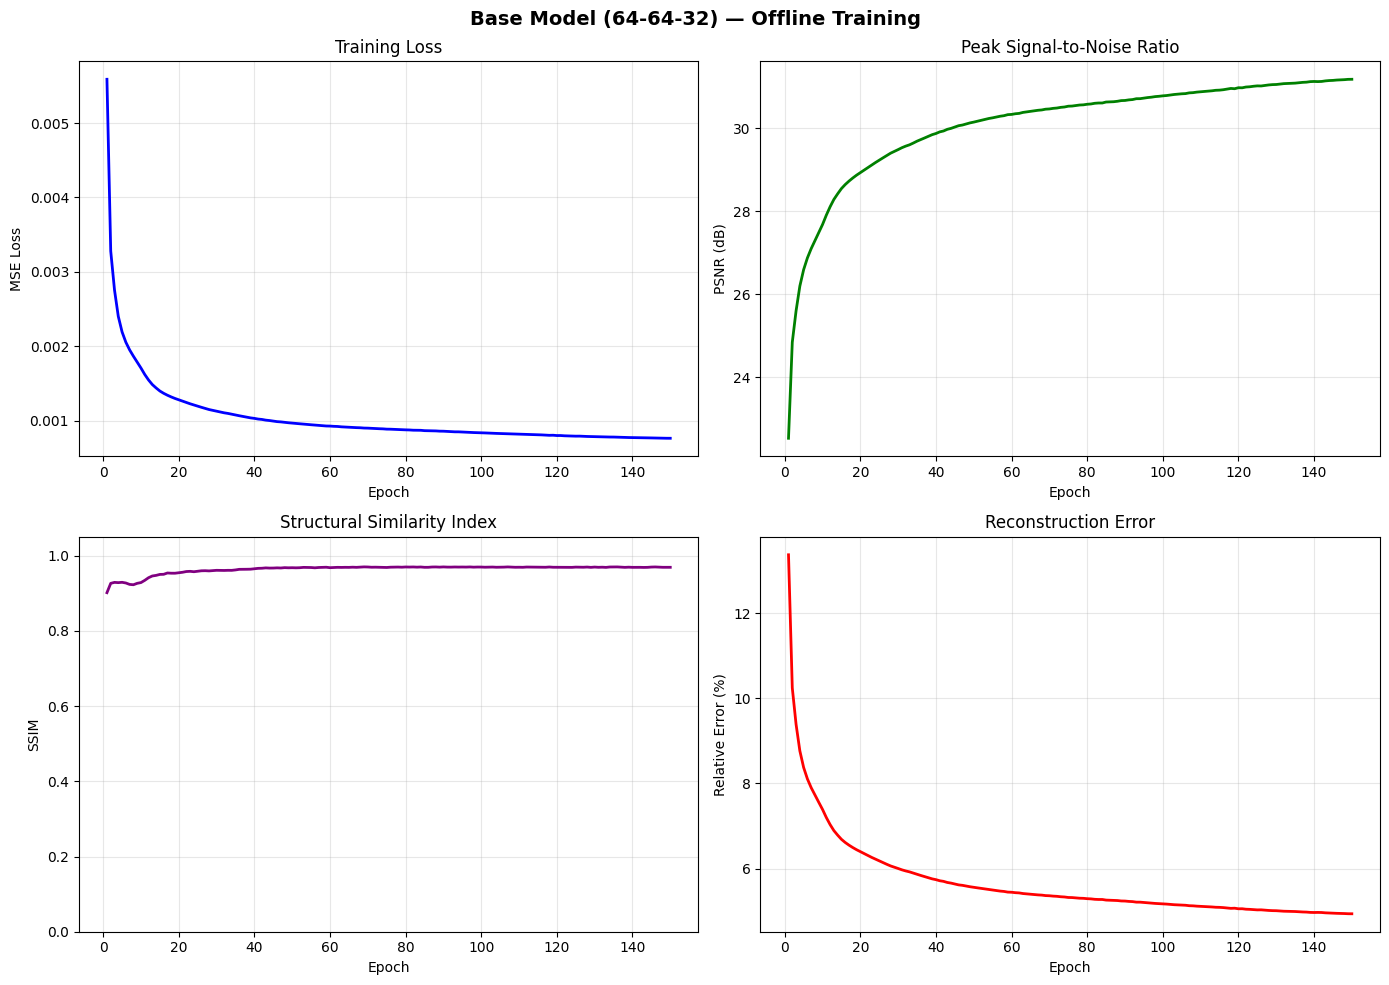

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, len(base_metrics['loss']) + 1)

axes[0, 0].plot(epochs_range, base_metrics['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, base_metrics['psnr'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, base_metrics['ssim'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(epochs_range, base_metrics['relative_error'], 'r-', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Base Model (64-64-32) \u2014 Offline Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_OUTPUT_DIR}/base_model_training_progress.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.1 Base Model — Evaluation & Visualization

In [6]:
base_model.eval()
print(f"[Eval] Base model: {sum(p.numel() for p in base_model.parameters()):,} parameters")

all_inputs = torch.from_numpy(dataset.inputs).to(device)
with torch.no_grad():
    base_predictions = base_model(all_inputs).cpu()

all_targets = torch.from_numpy(dataset.targets)

base_psnr, base_ssim = compute_psnr_ssim(base_predictions, all_targets, device)
base_rel_error = compute_relative_error(base_predictions, all_targets)
print(f"[Eval] PSNR: {base_psnr:.2f} dB | SSIM: {base_ssim:.4f} | Rel. Error: {base_rel_error:.2f}%")

# Use normalized data [0, 1] for visualization
base_pred_norm = base_predictions.numpy()
targets_norm = all_targets.numpy()
coords_denorm = dataset.denormalize_inputs(dataset.inputs)

timestep_mask = np.abs(coords_denorm[:, 3] - TIMESTEP) < 1e-6
x = coords_denorm[timestep_mask, 0]
y = coords_denorm[timestep_mask, 1]
base_pred_t = base_pred_norm[timestep_mask]
target_t = targets_norm[timestep_mask]
base_errors_t = np.abs(target_t - base_pred_t)

print(f"[Eval] Visualizing {len(x):,} points at timestep {TIMESTEP}")

[Eval] Base model: 6,692 parameters
[Eval] PSNR: 31.24 dB | SSIM: 0.9748 | Rel. Error: 4.90%
[Eval] Visualizing 26,397 points at timestep 0.0396


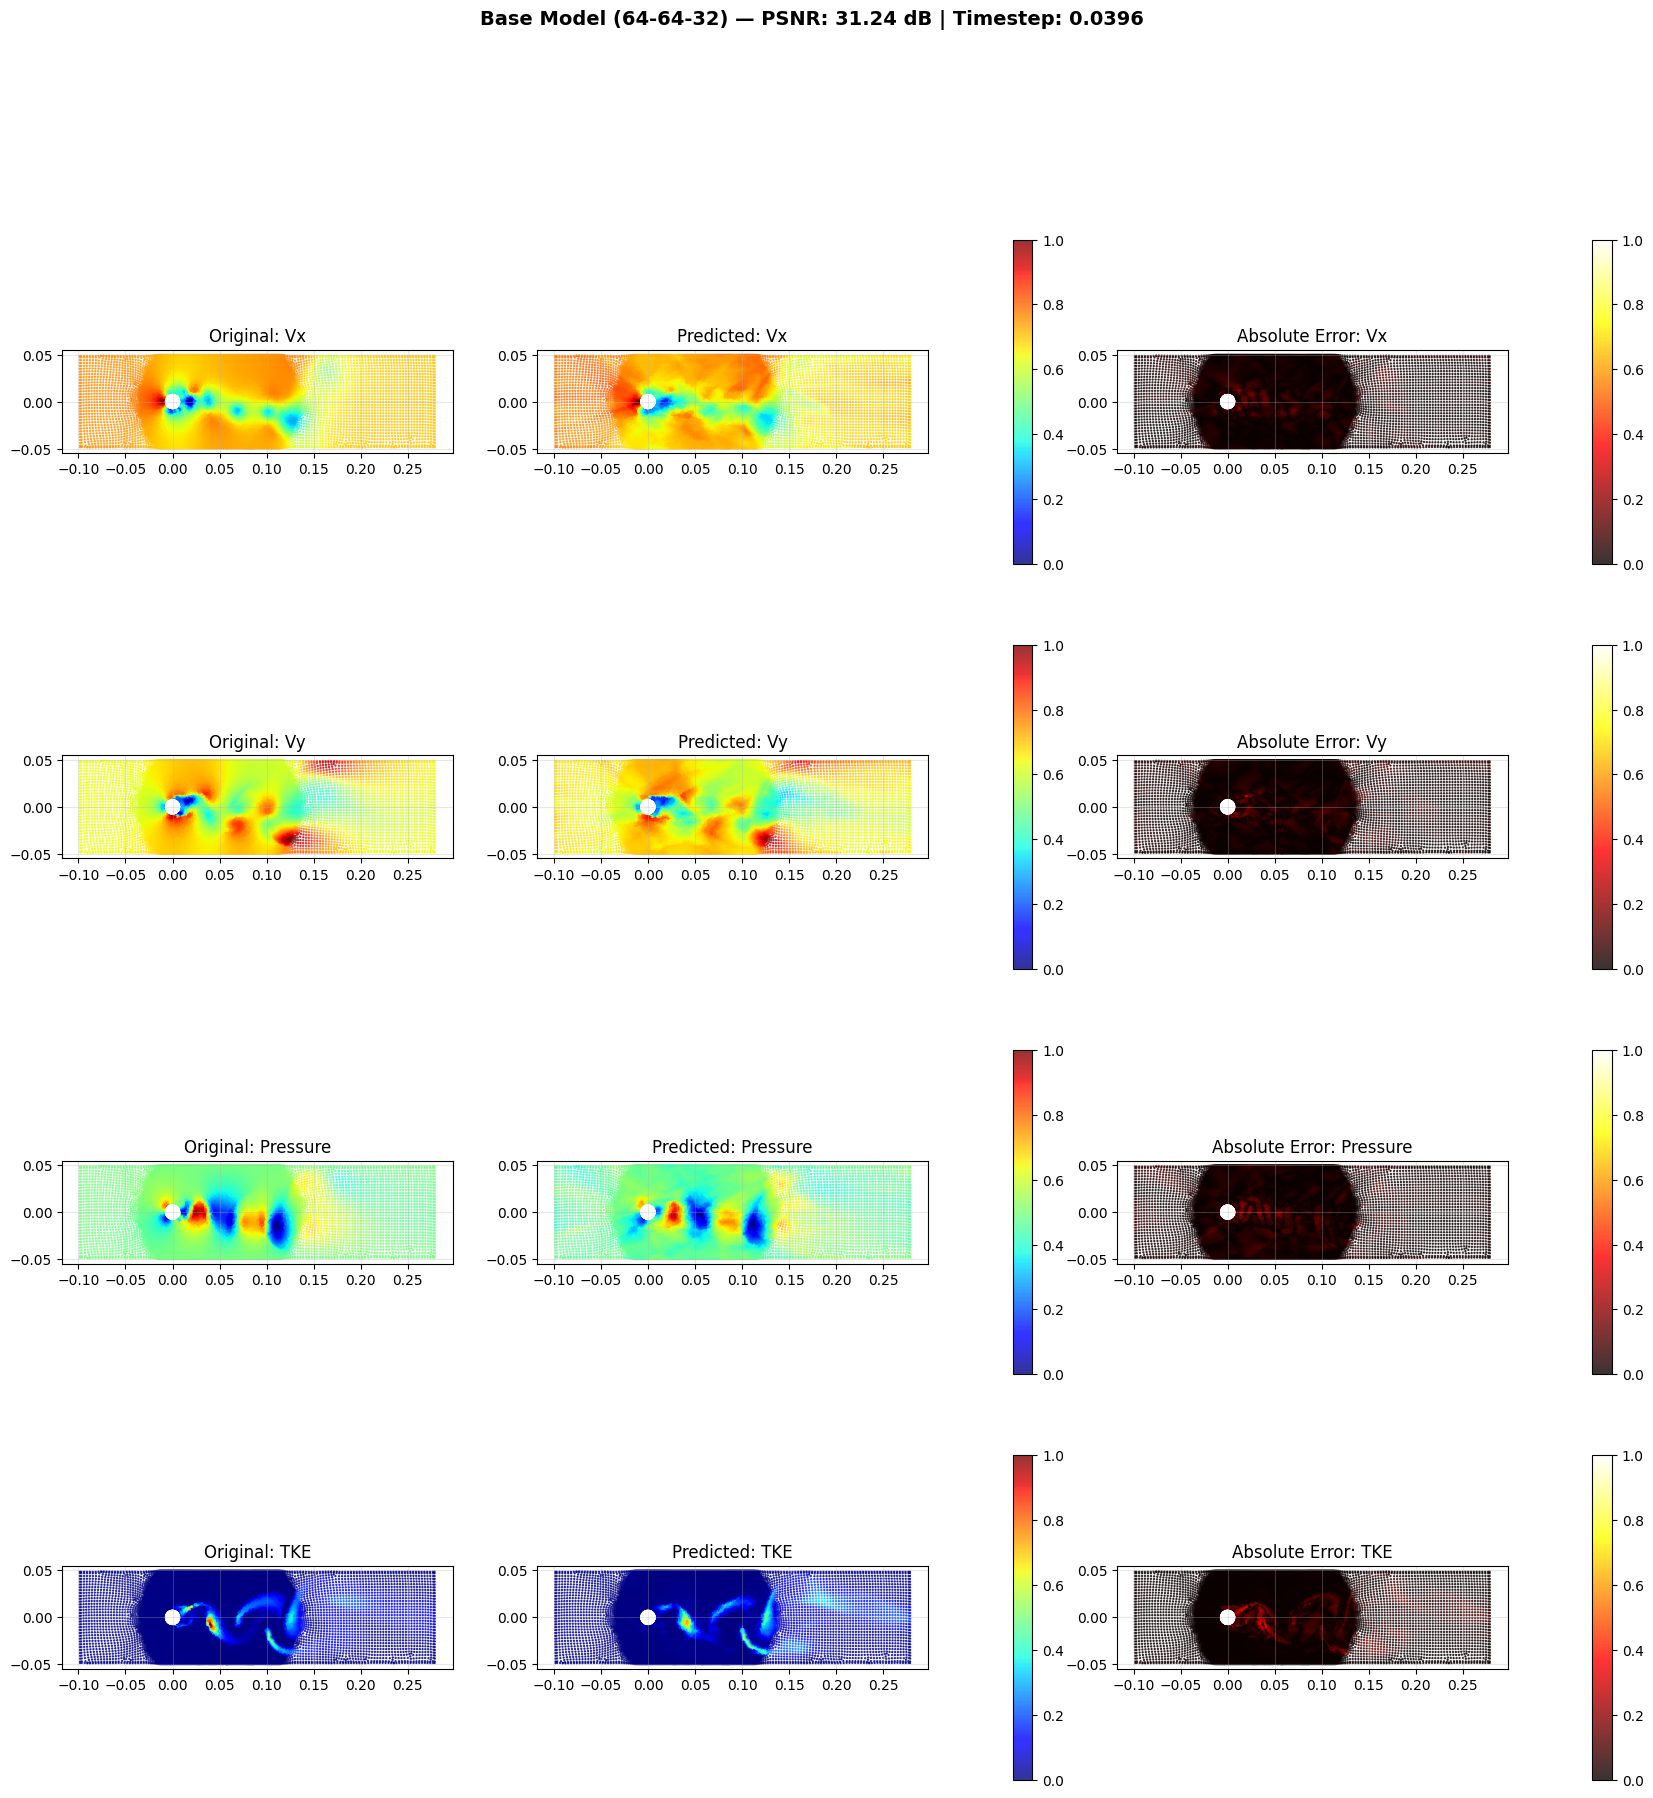

[Eval] Base model evaluation completed


In [7]:
from matplotlib.gridspec import GridSpec

feature_names = ['Vx', 'Vy', 'Pressure', 'TKE']

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(4, 5, figure=fig,
              width_ratios=[1, 1, 0.05, 1, 0.05],
              wspace=0.35, hspace=0.25)

for row, (idx, name) in enumerate(zip(range(4), feature_names)):
    original = target_t[:, idx]
    predicted = base_pred_t[:, idx]
    error = base_errors_t[:, idx]

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.scatter(x, y, c=original, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax0.set_title(f'Original: {name}')
    ax0.set_aspect('equal')
    ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[row, 1])
    sc2 = ax1.scatter(x, y, c=predicted, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax1.set_title(f'Predicted: {name}')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    cax1 = fig.add_subplot(gs[row, 2])
    fig.colorbar(sc2, cax=cax1)

    ax2 = fig.add_subplot(gs[row, 3])
    sc3 = ax2.scatter(x, y, c=error, cmap='hot', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax2.set_title(f'Absolute Error: {name}')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    cax2 = fig.add_subplot(gs[row, 4])
    fig.colorbar(sc3, cax=cax2)

fig.suptitle(f'Base Model (64-64-32) \u2014 PSNR: {base_psnr:.2f} dB | Timestep: {TIMESTEP}',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(f"{BASE_OUTPUT_DIR}/base_flow_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

base_eval = {
    'model': 'base_model_minmax.pth',
    'architecture': '4-64-64-32-4',
    'training_mode': 'offline_batch',
    'parameters': sum(p.numel() for p in base_model.parameters()),
    'psnr_db': float(base_psnr),
    'ssim': float(base_ssim),
    'relative_error_pct': float(base_rel_error)
}
with open(f"{BASE_OUTPUT_DIR}/evaluation_metrics.json", 'w') as f:
    json.dump(base_eval, f, indent=2)
print("[Eval] Base model evaluation completed")

---
## 2. Medium Model (96-96-48) — Training

In [8]:
MEDIUM_OUTPUT_DIR = "/kaggle/working/results/medium_model_offline"

medium_model = MediumCompressor().to(device)

medium_metrics = train_model(
    model=medium_model,
    train_loader=train_loader,
    dataset=dataset,
    device=device,
    epochs=EPOCHS,
    model_name='medium_model',
    output_dir=MEDIUM_OUTPUT_DIR
)

export_metrics_csv(medium_metrics, f"{MEDIUM_OUTPUT_DIR}/medium_model_metrics.csv")


[Train] Model: medium_model
[Train] Samples: 7,919,100 | Epochs: 150 | Device: cuda
[Train] Parameters: 14,644 | Size: 57.20 KB

  Epoch   1/150: Loss=0.005048, PSNR=22.97 dB, SSIM=0.9126, Rel. Error=12.71%, Time=76.88s
  Epoch  10/150: Loss=0.000984, PSNR=30.07 dB, SSIM=0.9778, Rel. Error=5.61%, Time=77.15s
  Epoch  20/150: Loss=0.000750, PSNR=31.25 dB, SSIM=0.9805, Rel. Error=4.90%, Time=78.26s
  Epoch  30/150: Loss=0.000635, PSNR=31.97 dB, SSIM=0.9816, Rel. Error=4.51%, Time=77.39s
  Epoch  40/150: Loss=0.000576, PSNR=32.40 dB, SSIM=0.9820, Rel. Error=4.29%, Time=77.70s
  Epoch  50/150: Loss=0.000541, PSNR=32.67 dB, SSIM=0.9828, Rel. Error=4.16%, Time=76.75s
  Epoch  60/150: Loss=0.000518, PSNR=32.86 dB, SSIM=0.9824, Rel. Error=4.07%, Time=77.04s
  Epoch  70/150: Loss=0.000499, PSNR=33.02 dB, SSIM=0.9824, Rel. Error=4.00%, Time=78.32s
  Epoch  80/150: Loss=0.000482, PSNR=33.17 dB, SSIM=0.9829, Rel. Error=3.93%, Time=77.22s
  Epoch  90/150: Loss=0.000469, PSNR=33.29 dB, SSIM=0.9830,

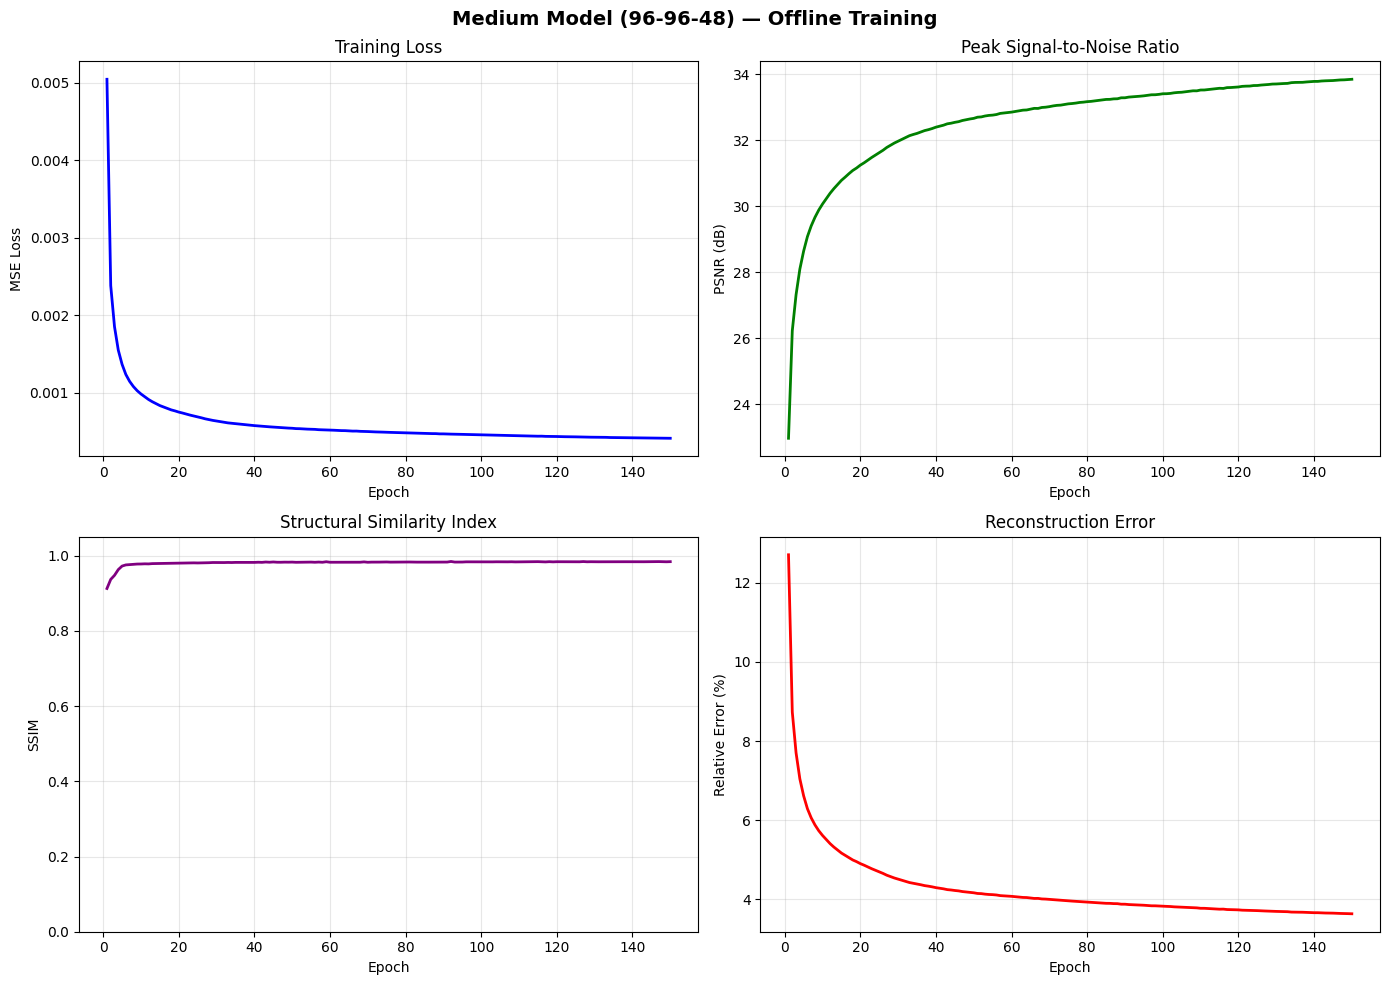

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, len(medium_metrics['loss']) + 1)

axes[0, 0].plot(epochs_range, medium_metrics['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, medium_metrics['psnr'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, medium_metrics['ssim'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(epochs_range, medium_metrics['relative_error'], 'r-', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Medium Model (96-96-48) \u2014 Offline Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MEDIUM_OUTPUT_DIR}/medium_model_training_progress.png", dpi=300, bbox_inches='tight')
plt.show()

### 2.1 Medium Model — Evaluation & Visualization

In [10]:
medium_model.eval()
print(f"[Eval] Medium model: {sum(p.numel() for p in medium_model.parameters()):,} parameters")

with torch.no_grad():
    medium_predictions = medium_model(all_inputs).cpu()

medium_psnr, medium_ssim = compute_psnr_ssim(medium_predictions, all_targets, device)
medium_rel_error = compute_relative_error(medium_predictions, all_targets)
print(f"[Eval] PSNR: {medium_psnr:.2f} dB | SSIM: {medium_ssim:.4f} | Rel. Error: {medium_rel_error:.2f}%")

medium_pred_norm = medium_predictions.numpy()
medium_pred_t = medium_pred_norm[timestep_mask]
medium_errors_t = np.abs(target_t - medium_pred_t)

print(f"[Eval] Visualizing {len(x):,} points at timestep {TIMESTEP}")

[Eval] Medium model: 14,644 parameters
[Eval] PSNR: 34.18 dB | SSIM: 0.9853 | Rel. Error: 3.49%
[Eval] Visualizing 26,397 points at timestep 0.0396


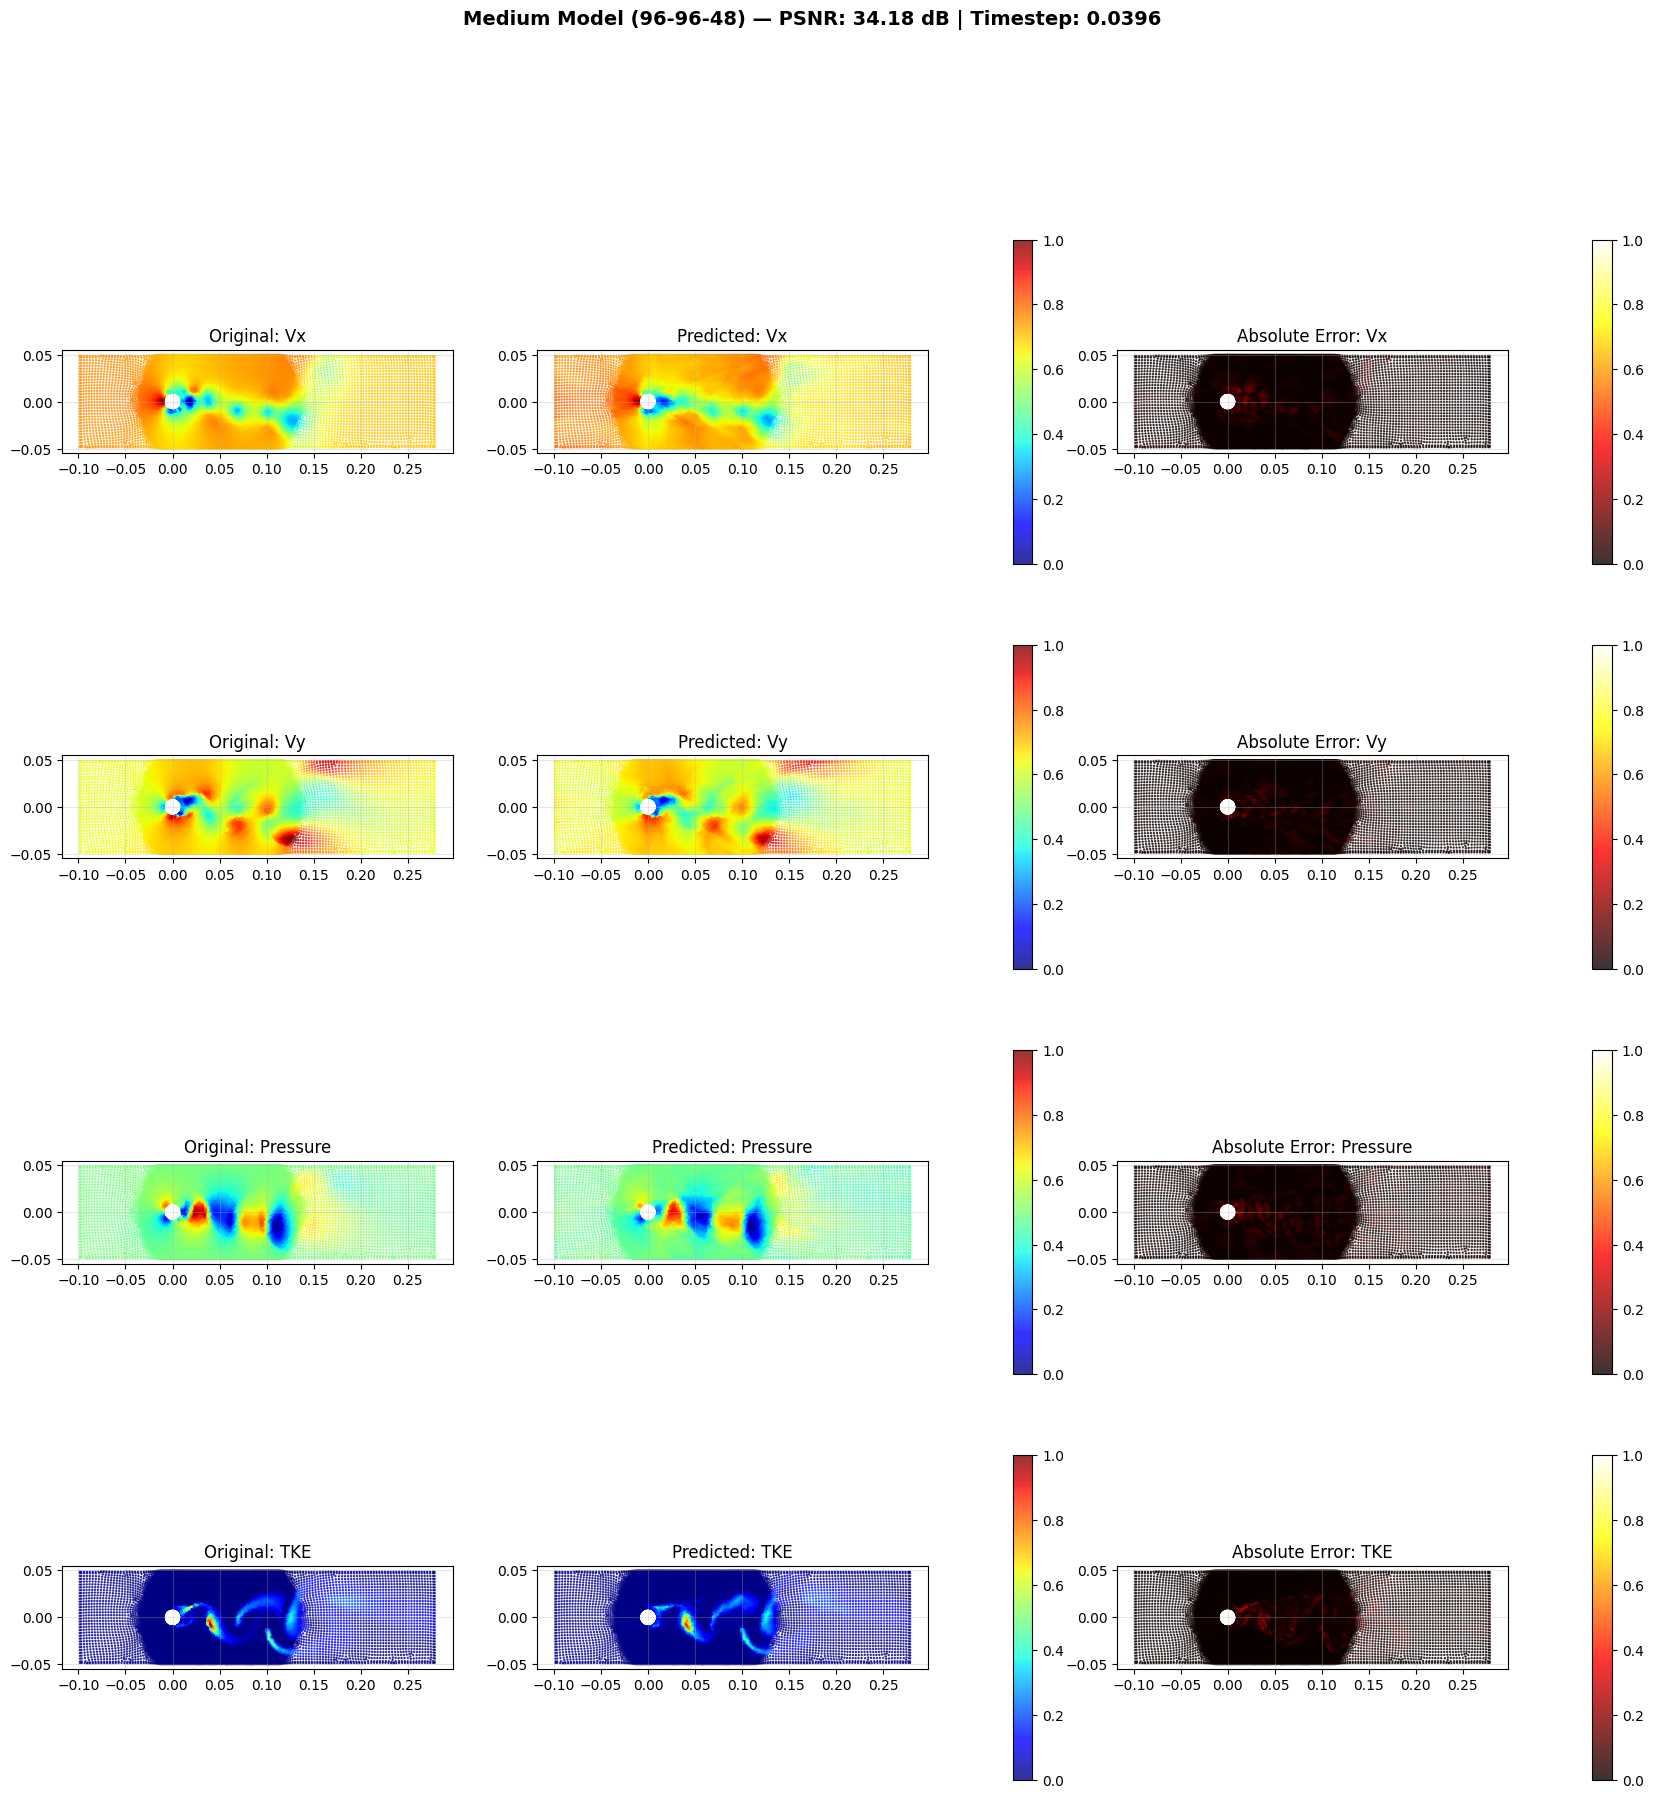

[Eval] Medium model evaluation completed


In [11]:
feature_names = ['Vx', 'Vy', 'Pressure', 'TKE']

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(4, 5, figure=fig,
              width_ratios=[1, 1, 0.05, 1, 0.05],
              wspace=0.35, hspace=0.25)

for row, (idx, name) in enumerate(zip(range(4), feature_names)):
    original = target_t[:, idx]
    predicted = medium_pred_t[:, idx]
    error = medium_errors_t[:, idx]

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.scatter(x, y, c=original, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax0.set_title(f'Original: {name}')
    ax0.set_aspect('equal')
    ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[row, 1])
    sc2 = ax1.scatter(x, y, c=predicted, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax1.set_title(f'Predicted: {name}')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    cax1 = fig.add_subplot(gs[row, 2])
    fig.colorbar(sc2, cax=cax1)

    ax2 = fig.add_subplot(gs[row, 3])
    sc3 = ax2.scatter(x, y, c=error, cmap='hot', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax2.set_title(f'Absolute Error: {name}')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    cax2 = fig.add_subplot(gs[row, 4])
    fig.colorbar(sc3, cax=cax2)

fig.suptitle(f'Medium Model (96-96-48) \u2014 PSNR: {medium_psnr:.2f} dB | Timestep: {TIMESTEP}',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(f"{MEDIUM_OUTPUT_DIR}/medium_flow_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

medium_eval = {
    'model': 'medium_model_minmax.pth',
    'architecture': '4-96-96-48-4',
    'training_mode': 'offline_batch',
    'parameters': sum(p.numel() for p in medium_model.parameters()),
    'psnr_db': float(medium_psnr),
    'ssim': float(medium_ssim),
    'relative_error_pct': float(medium_rel_error)
}
with open(f"{MEDIUM_OUTPUT_DIR}/evaluation_metrics.json", 'w') as f:
    json.dump(medium_eval, f, indent=2)
print("[Eval] Medium model evaluation completed")

---
## 3. Large Model (128-128-64) — Training

In [12]:
LARGE_OUTPUT_DIR = "/kaggle/working/results/large_model_offline"

large_model = LargeCompressor().to(device)

large_metrics = train_model(
    model=large_model,
    train_loader=train_loader,
    dataset=dataset,
    device=device,
    epochs=EPOCHS,
    model_name='large_model',
    output_dir=LARGE_OUTPUT_DIR
)

export_metrics_csv(large_metrics, f"{LARGE_OUTPUT_DIR}/large_model_metrics.csv")


[Train] Model: large_model
[Train] Samples: 7,919,100 | Epochs: 150 | Device: cuda
[Train] Parameters: 25,668 | Size: 100.27 KB

  Epoch   1/150: Loss=0.004380, PSNR=23.58 dB, SSIM=0.9146, Rel. Error=11.84%, Time=78.99s
  Epoch  10/150: Loss=0.000731, PSNR=31.36 dB, SSIM=0.9481, Rel. Error=4.84%, Time=77.90s
  Epoch  20/150: Loss=0.000532, PSNR=32.74 dB, SSIM=0.9618, Rel. Error=4.13%, Time=77.84s
  Epoch  30/150: Loss=0.000456, PSNR=33.41 dB, SSIM=0.9663, Rel. Error=3.82%, Time=79.61s
  Epoch  40/150: Loss=0.000415, PSNR=33.82 dB, SSIM=0.9698, Rel. Error=3.64%, Time=77.74s
  Epoch  50/150: Loss=0.000384, PSNR=34.16 dB, SSIM=0.9718, Rel. Error=3.51%, Time=78.31s
  Epoch  60/150: Loss=0.000361, PSNR=34.42 dB, SSIM=0.9725, Rel. Error=3.40%, Time=77.81s
  Epoch  70/150: Loss=0.000346, PSNR=34.60 dB, SSIM=0.9731, Rel. Error=3.33%, Time=78.61s
  Epoch  80/150: Loss=0.000332, PSNR=34.79 dB, SSIM=0.9758, Rel. Error=3.26%, Time=76.85s
  Epoch  90/150: Loss=0.000324, PSNR=34.90 dB, SSIM=0.9746,

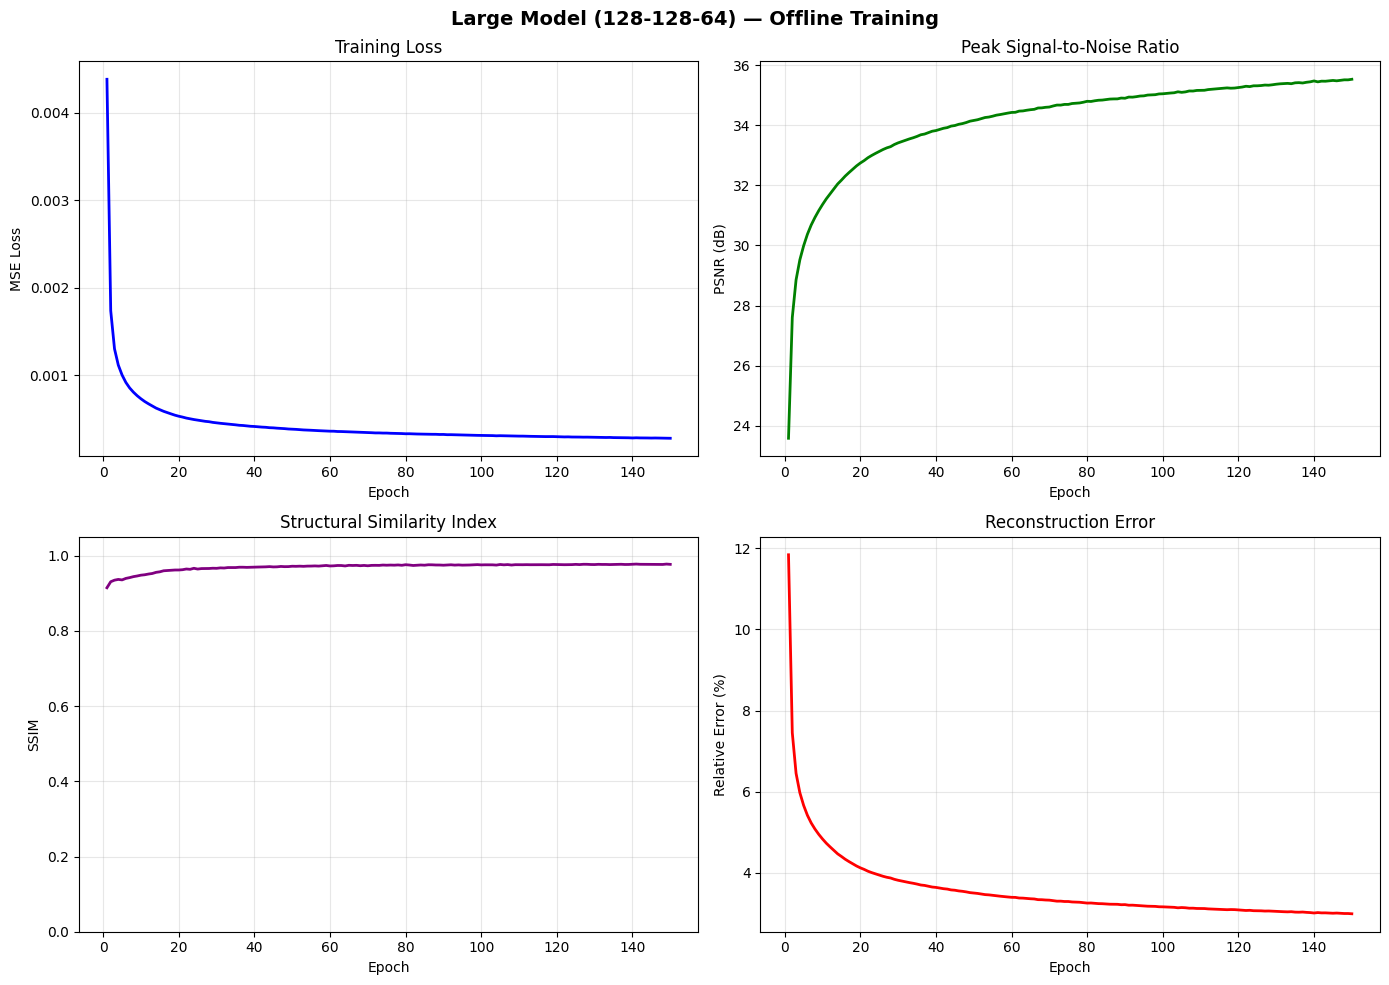

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, len(large_metrics['loss']) + 1)

axes[0, 0].plot(epochs_range, large_metrics['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, large_metrics['psnr'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, large_metrics['ssim'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(epochs_range, large_metrics['relative_error'], 'r-', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Large Model (128-128-64) \u2014 Offline Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LARGE_OUTPUT_DIR}/large_model_training_progress.png", dpi=300, bbox_inches='tight')
plt.show()

### 3.1 Large Model — Evaluation & Visualization

In [14]:
large_model.eval()
print(f"[Eval] Large model: {sum(p.numel() for p in large_model.parameters()):,} parameters")

with torch.no_grad():
    large_predictions = large_model(all_inputs).cpu()

large_psnr, large_ssim = compute_psnr_ssim(large_predictions, all_targets, device)
large_rel_error = compute_relative_error(large_predictions, all_targets)
print(f"[Eval] PSNR: {large_psnr:.2f} dB | SSIM: {large_ssim:.4f} | Rel. Error: {large_rel_error:.2f}%")

large_pred_norm = large_predictions.numpy()
large_pred_t = large_pred_norm[timestep_mask]
large_errors_t = np.abs(target_t - large_pred_t)

print(f"[Eval] Visualizing {len(x):,} points at timestep {TIMESTEP}")

[Eval] Large model: 25,668 parameters
[Eval] PSNR: 35.72 dB | SSIM: 0.9823 | Rel. Error: 2.92%
[Eval] Visualizing 26,397 points at timestep 0.0396


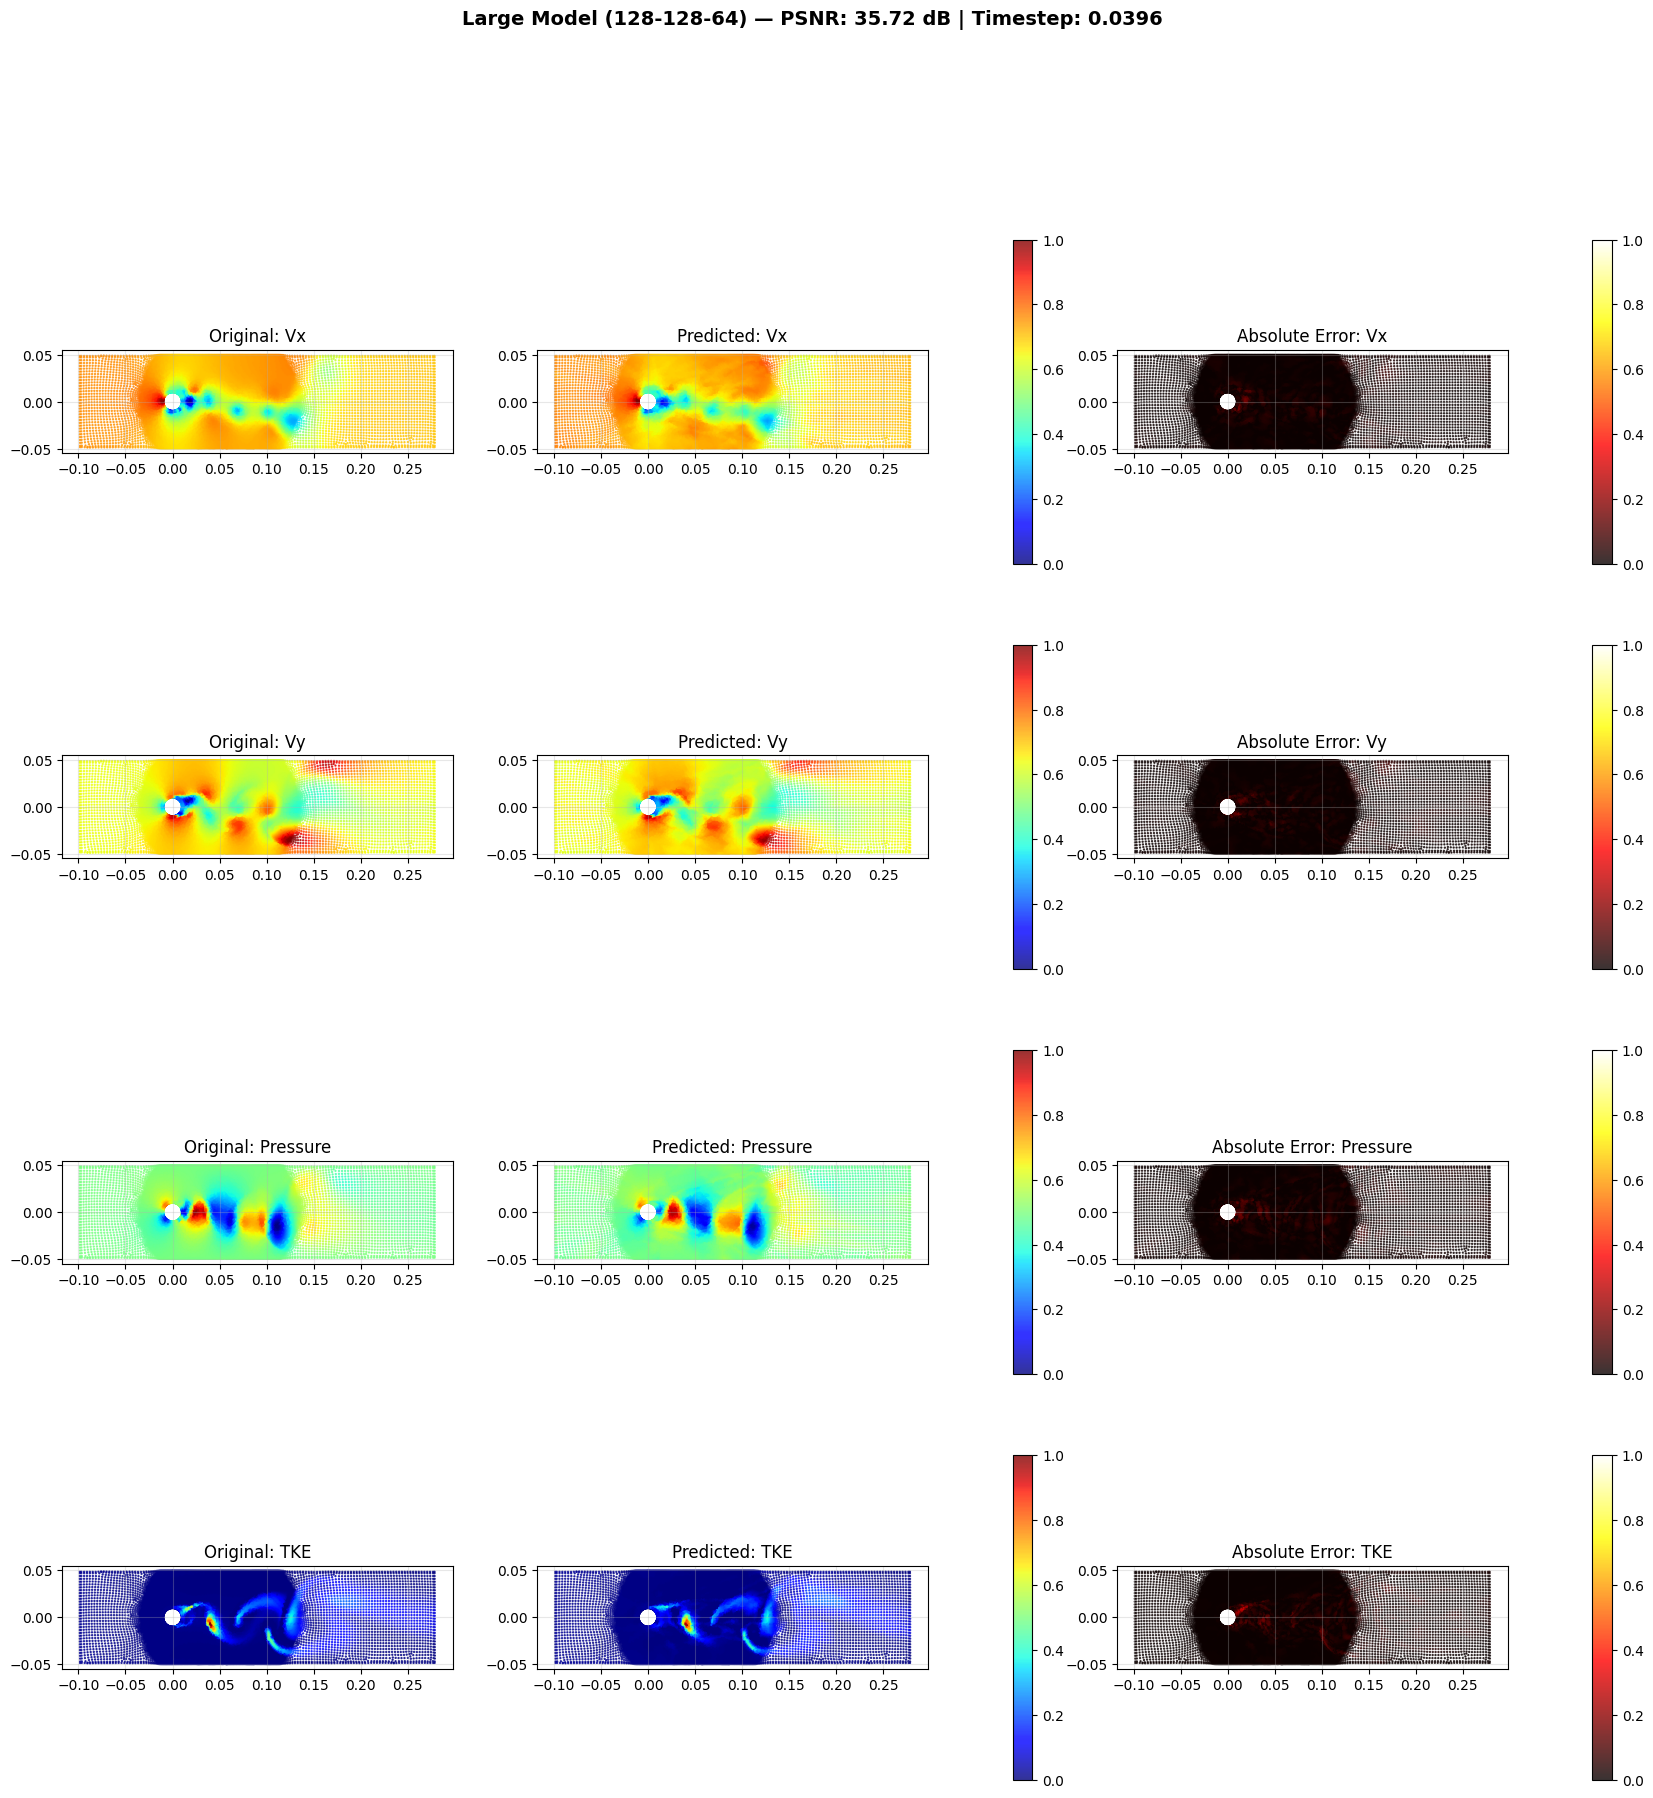

[Eval] Large model evaluation completed


In [15]:
feature_names = ['Vx', 'Vy', 'Pressure', 'TKE']

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(4, 5, figure=fig,
              width_ratios=[1, 1, 0.05, 1, 0.05],
              wspace=0.35, hspace=0.25)

for row, (idx, name) in enumerate(zip(range(4), feature_names)):
    original = target_t[:, idx]
    predicted = large_pred_t[:, idx]
    error = large_errors_t[:, idx]

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.scatter(x, y, c=original, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax0.set_title(f'Original: {name}')
    ax0.set_aspect('equal')
    ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[row, 1])
    sc2 = ax1.scatter(x, y, c=predicted, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax1.set_title(f'Predicted: {name}')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    cax1 = fig.add_subplot(gs[row, 2])
    fig.colorbar(sc2, cax=cax1)

    ax2 = fig.add_subplot(gs[row, 3])
    sc3 = ax2.scatter(x, y, c=error, cmap='hot', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax2.set_title(f'Absolute Error: {name}')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    cax2 = fig.add_subplot(gs[row, 4])
    fig.colorbar(sc3, cax=cax2)

fig.suptitle(f'Large Model (128-128-64) \u2014 PSNR: {large_psnr:.2f} dB | Timestep: {TIMESTEP}',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(f"{LARGE_OUTPUT_DIR}/large_flow_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

large_eval = {
    'model': 'large_model_minmax.pth',
    'architecture': '4-128-128-64-4',
    'training_mode': 'offline_batch',
    'parameters': sum(p.numel() for p in large_model.parameters()),
    'psnr_db': float(large_psnr),
    'ssim': float(large_ssim),
    'relative_error_pct': float(large_rel_error)
}
with open(f"{LARGE_OUTPUT_DIR}/evaluation_metrics.json", 'w') as f:
    json.dump(large_eval, f, indent=2)
print("[Eval] Large model evaluation completed")

---
## 4. Combined Comparison — All Three Models

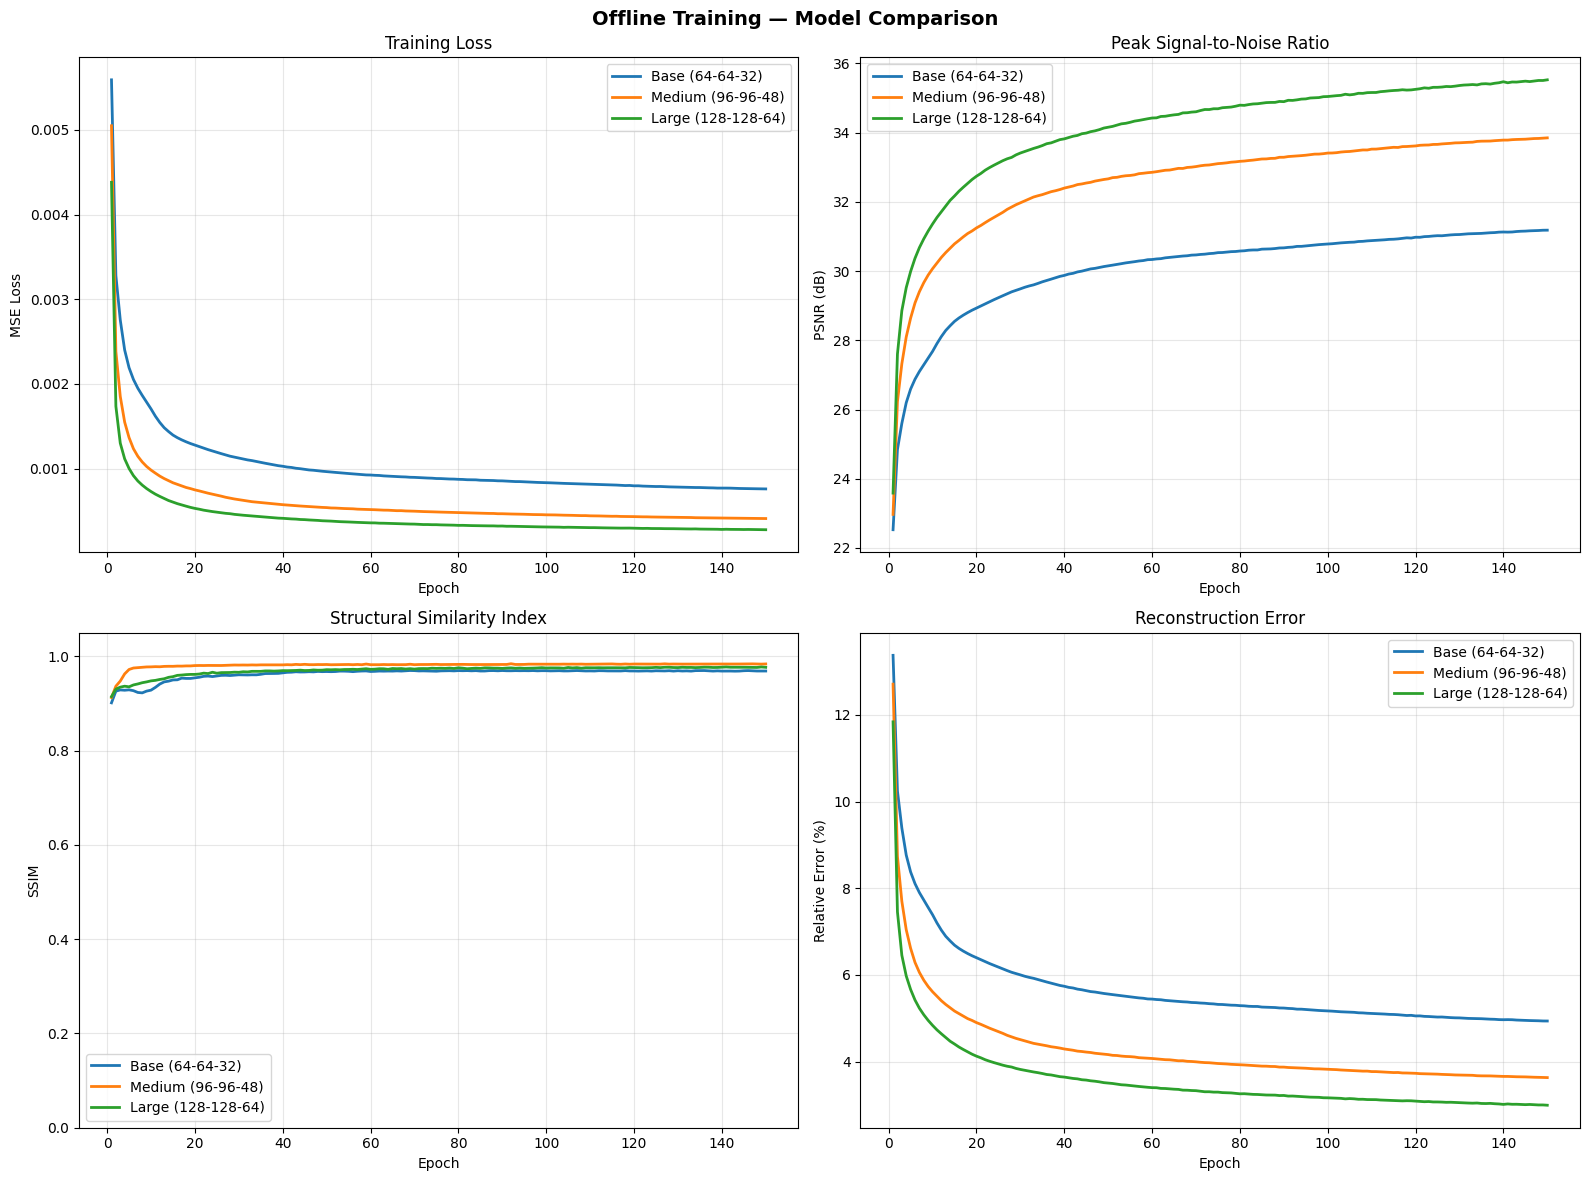

In [16]:
COMPARISON_DIR = "/kaggle/working/results/comparison_offline"
os.makedirs(COMPARISON_DIR, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('Base (64-64-32)', base_metrics, 'tab:blue'),
    ('Medium (96-96-48)', medium_metrics, 'tab:orange'),
    ('Large (128-128-64)', large_metrics, 'tab:green')
]

for label, m, color in models_data:
    epochs_range = range(1, len(m['loss']) + 1)
    axes[0, 0].plot(epochs_range, m['loss'], '-', color=color, linewidth=2, label=label)
    axes[0, 1].plot(epochs_range, m['psnr'], '-', color=color, linewidth=2, label=label)
    axes[1, 0].plot(epochs_range, m['ssim'], '-', color=color, linewidth=2, label=label)
    axes[1, 1].plot(epochs_range, m['relative_error'], '-', color=color, linewidth=2, label=label)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].legend()

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle('Offline Training \u2014 Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/offline_training_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

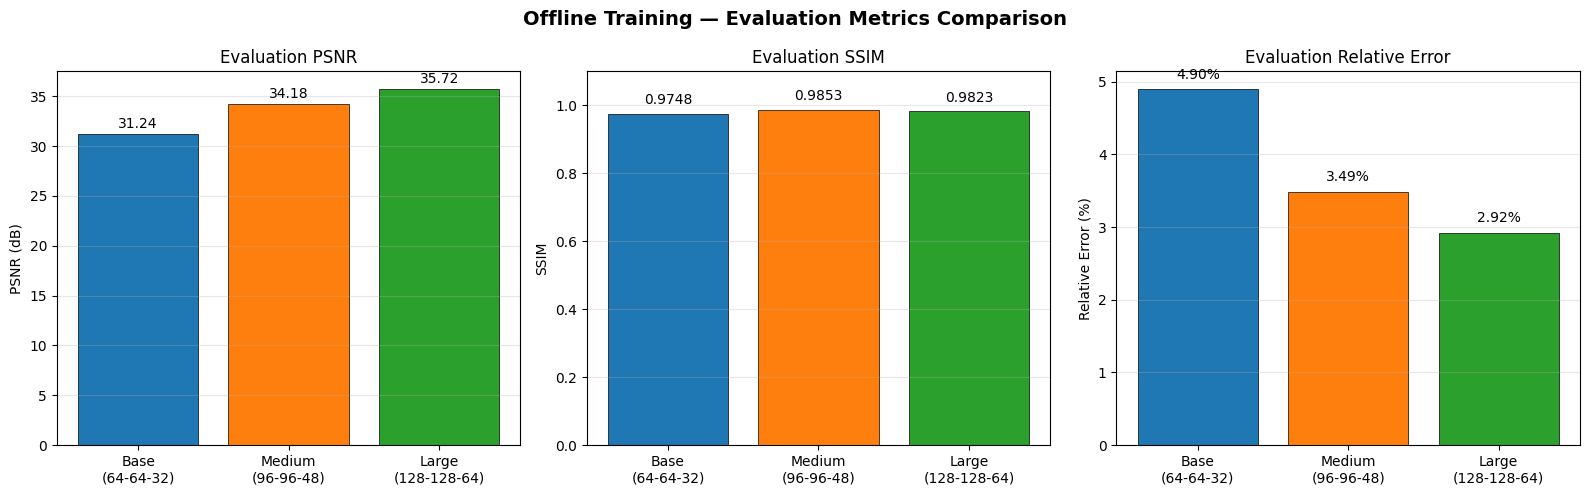

In [17]:
# Combined evaluation bar chart
model_names = ['Base\n(64-64-32)', 'Medium\n(96-96-48)', 'Large\n(128-128-64)']
eval_psnrs = [base_psnr, medium_psnr, large_psnr]
eval_ssims = [base_ssim, medium_ssim, large_ssim]
eval_errors = [base_rel_error, medium_rel_error, large_rel_error]
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars1 = axes[0].bar(model_names, eval_psnrs, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Evaluation PSNR')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, eval_psnrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(model_names, eval_ssims, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('SSIM')
axes[1].set_title('Evaluation SSIM')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1.1])
for bar, val in zip(bars2, eval_ssims):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

bars3 = axes[2].bar(model_names, eval_errors, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Relative Error (%)')
axes[2].set_title('Evaluation Relative Error')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, eval_errors):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Offline Training \u2014 Evaluation Metrics Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/offline_evaluation_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
print("=" * 80)
print("OFFLINE TRAINING \u2014 THREE-MODEL COMPARISON SUMMARY")
print("=" * 80)
print(f"{'Metric':<28} {'Base (64-64-32)':>16} {'Medium (96-96-48)':>18} {'Large (128-128-64)':>20}")
print("-" * 80)
print(f"{'Parameters':<28} {sum(p.numel() for p in base_model.parameters()):>16,} {sum(p.numel() for p in medium_model.parameters()):>18,} {sum(p.numel() for p in large_model.parameters()):>20,}")
print(f"{'Model Size (KB)':<28} {sum(p.numel() for p in base_model.parameters()) * 4 / 1024:>16.2f} {sum(p.numel() for p in medium_model.parameters()) * 4 / 1024:>18.2f} {sum(p.numel() for p in large_model.parameters()) * 4 / 1024:>20.2f}")
print(f"{'Epochs':<28} {EPOCHS:>16} {EPOCHS:>18} {EPOCHS:>20}")
print("-" * 80)
print(f"{'Final Train Loss':<28} {base_metrics['loss'][-1]:>16.6f} {medium_metrics['loss'][-1]:>18.6f} {large_metrics['loss'][-1]:>20.6f}")
print(f"{'Final Train PSNR (dB)':<28} {base_metrics['psnr'][-1]:>16.2f} {medium_metrics['psnr'][-1]:>18.2f} {large_metrics['psnr'][-1]:>20.2f}")
print(f"{'Final Train SSIM':<28} {base_metrics['ssim'][-1]:>16.4f} {medium_metrics['ssim'][-1]:>18.4f} {large_metrics['ssim'][-1]:>20.4f}")
print(f"{'Final Rel. Error (%)':<28} {base_metrics['relative_error'][-1]:>16.2f} {medium_metrics['relative_error'][-1]:>18.2f} {large_metrics['relative_error'][-1]:>20.2f}")
print("-" * 80)
print(f"{'Eval PSNR (dB)':<28} {base_psnr:>16.2f} {medium_psnr:>18.2f} {large_psnr:>20.2f}")
print(f"{'Eval SSIM':<28} {base_ssim:>16.4f} {medium_ssim:>18.4f} {large_ssim:>20.4f}")
print(f"{'Eval Rel. Error (%)':<28} {base_rel_error:>16.2f} {medium_rel_error:>18.2f} {large_rel_error:>20.2f}")
print(f"{'Total Training Time (s)':<28} {sum(base_metrics['time_per_epoch']):>16.2f} {sum(medium_metrics['time_per_epoch']):>18.2f} {sum(large_metrics['time_per_epoch']):>20.2f}")
print("=" * 80)

OFFLINE TRAINING — THREE-MODEL COMPARISON SUMMARY
Metric                        Base (64-64-32)  Medium (96-96-48)   Large (128-128-64)
--------------------------------------------------------------------------------
Parameters                              6,692             14,644               25,668
Model Size (KB)                         26.14              57.20               100.27
Epochs                                    150                150                  150
--------------------------------------------------------------------------------
Final Train Loss                     0.000762           0.000412             0.000280
Final Train PSNR (dB)                   31.18              33.85                35.53
Final Train SSIM                       0.9690             0.9840               0.9768
Final Rel. Error (%)                     4.94               3.63                 2.99
--------------------------------------------------------------------------------
Eval PSNR (dB)     

---
## 5. Single-Axis Metric Comparisons (All Models Overlaid)

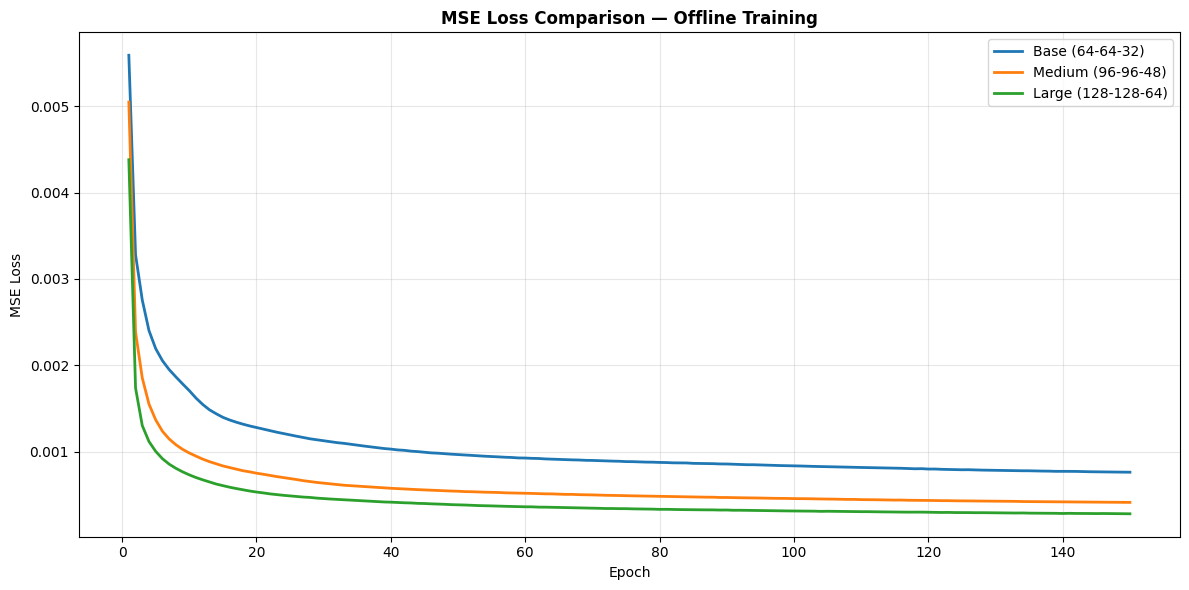

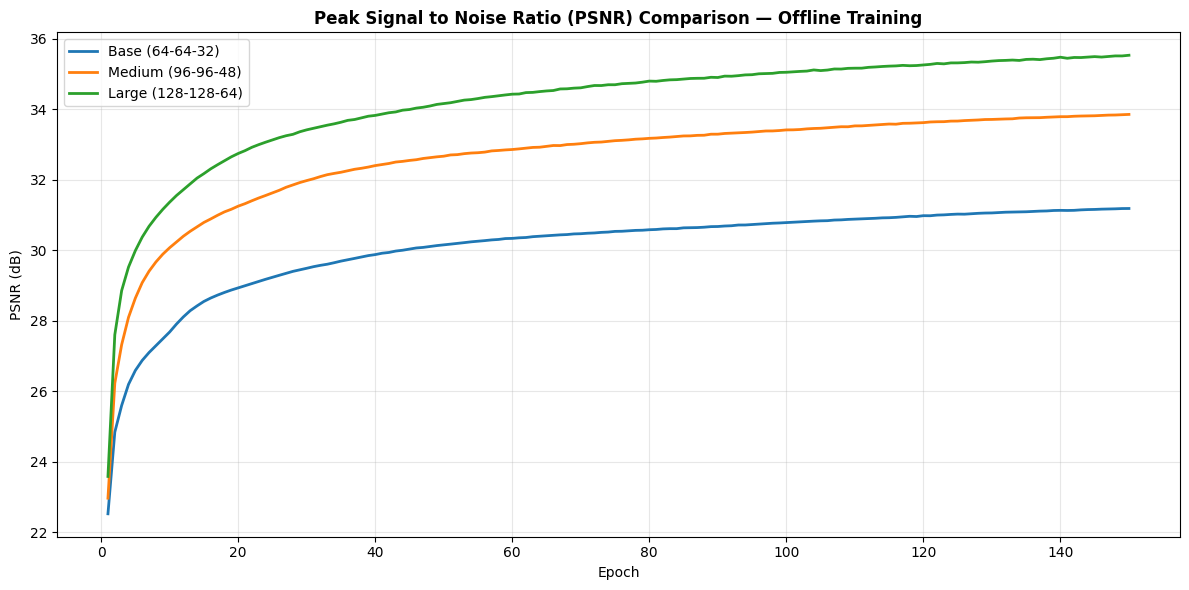

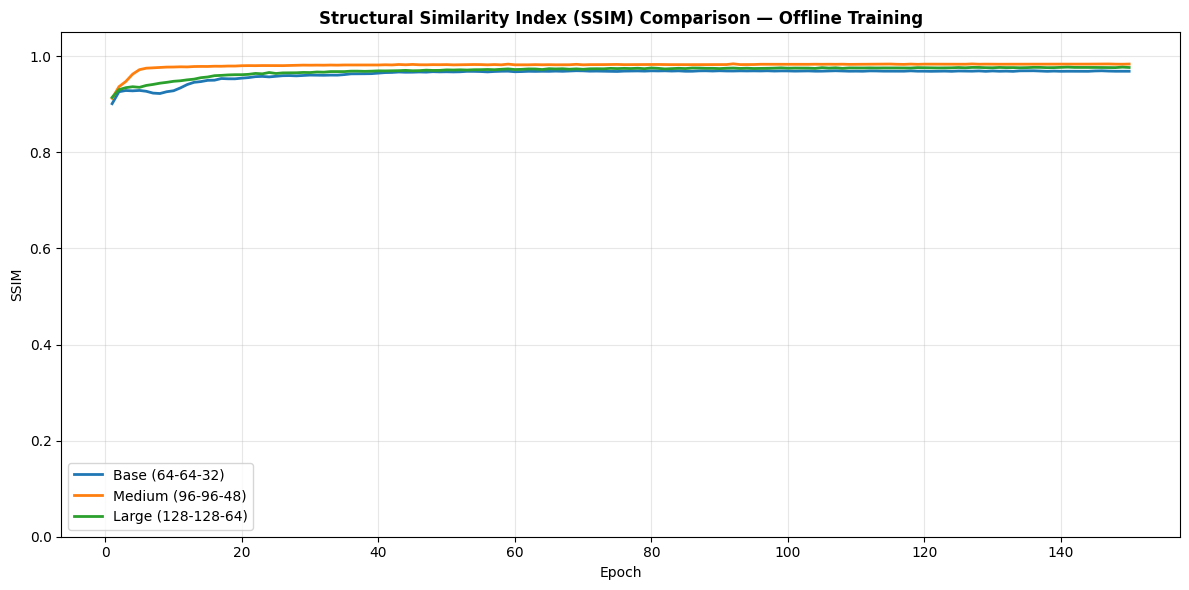

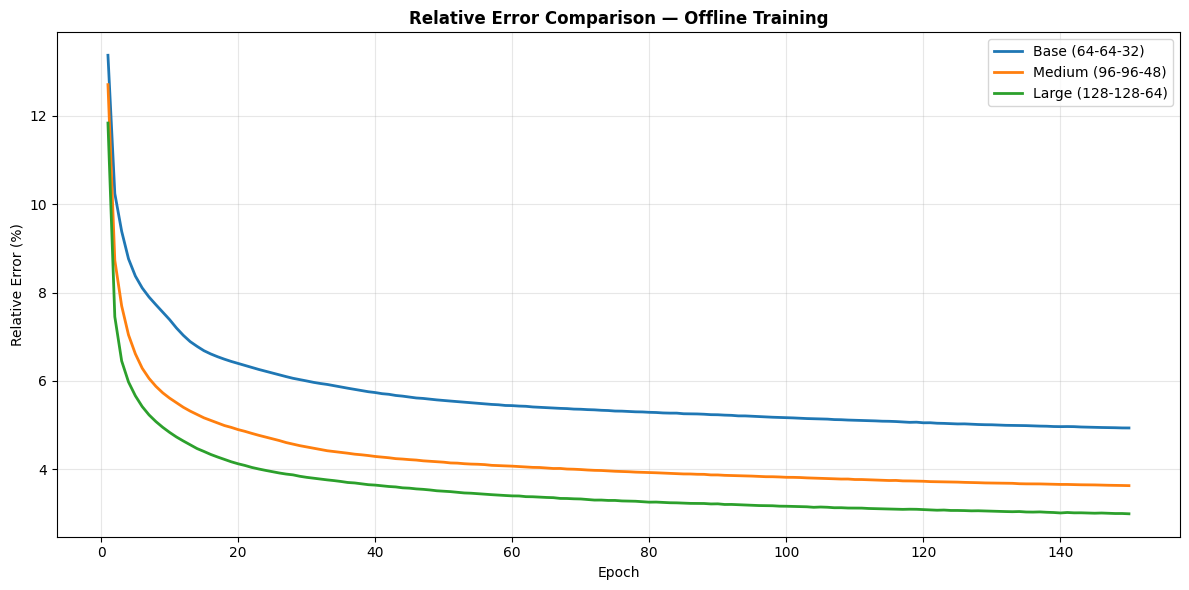

All comparison plots saved to /kaggle/working/results/comparison_offline/


In [19]:
models_overlay = [
    ('Base (64-64-32)', base_metrics, 'tab:blue'),
    ('Medium (96-96-48)', medium_metrics, 'tab:orange'),
    ('Large (128-128-64)', large_metrics, 'tab:green'),
]

# MSE Loss Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    epochs_range = range(1, len(m['loss']) + 1)
    ax.plot(epochs_range, m['loss'], linewidth=2, color=color, label=label)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('MSE Loss Comparison — Offline Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/loss_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# PSNR Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    epochs_range = range(1, len(m['psnr']) + 1)
    ax.plot(epochs_range, m['psnr'], linewidth=2, color=color, label=label)
ax.set_xlabel('Epoch')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Peak Signal to Noise Ratio (PSNR) Comparison — Offline Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/psnr_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# SSIM Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    epochs_range = range(1, len(m['ssim']) + 1)
    ax.plot(epochs_range, m['ssim'], linewidth=2, color=color, label=label)
ax.set_xlabel('Epoch')
ax.set_ylabel('SSIM')
ax.set_title('Structural Similarity Index (SSIM) Comparison — Offline Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/ssim_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Relative Error Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    epochs_range = range(1, len(m['relative_error']) + 1)
    ax.plot(epochs_range, m['relative_error'], linewidth=2, color=color, label=label)
ax.set_xlabel('Epoch')
ax.set_ylabel('Relative Error (%)')
ax.set_title('Relative Error Comparison — Offline Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/relative_error_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"All comparison plots saved to {COMPARISON_DIR}/")

### 6. Save and Download

In [20]:
# Package all results into a single zip for download

import shutil

zip_path = shutil.make_archive(
    '/kaggle/working/all_results',
    'zip',
    '/kaggle/working/results'
)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print("Results archived to: {}".format(zip_path))
print("Archive size: {:.1f} MB".format(zip_size_mb))

Results archived to: /kaggle/working/all_results.zip
Archive size: 7.8 MB
